# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [13]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

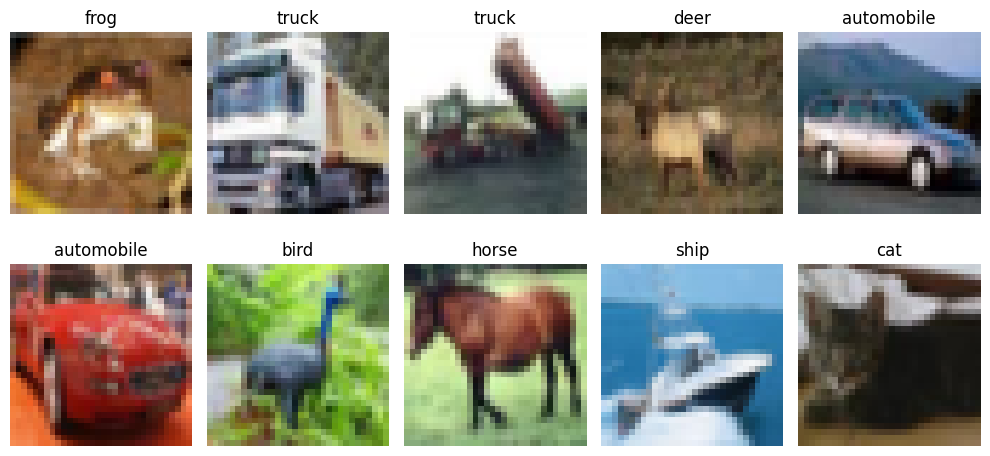

In [14]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [15]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.2254 - loss: 2.0706 - val_accuracy: 0.2952 - val_loss: 1.9322
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.2716 - loss: 1.9528 - val_accuracy: 0.3146 - val_loss: 1.9064
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.2937 - loss: 1.9069 - val_accuracy: 0.3160 - val_loss: 1.8963
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3011 - loss: 1.8824 - val_accuracy: 0.3370 - val_loss: 1.8625
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.3132 - loss: 1.8622 - val_accuracy: 0.3468 - val_loss: 1.8502
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.3181 - loss: 1.8437 - val_accuracy: 0.3566 - val_loss: 1.8219
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3224 - loss: 1.8329 - val_accuracy: 0.3524 - val_loss: 1.8161
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.3273 - loss: 1.8232 - 

In [19]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3952 - loss: 1.7066
ANN Test Accuracy: 0.3952000141143799


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [20]:
cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 246s 347ms/step - accuracy: 0.4186 - loss: 1.6554 - val_accuracy: 0.4826 - val_loss: 1.4551
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 343ms/step - accuracy: 0.5729 - loss: 1.2151 - val_accuracy: 0.5444 - val_loss: 1.3065
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 267s 350ms/step - accuracy: 0.6520 - loss: 1.0100 - val_accuracy: 0.6336 - val_loss: 1.0281
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 349ms/step - accuracy: 0.6986 - loss: 0.8747 - val_accuracy: 0.5844 - val_loss: 1.1643
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 245s 348ms/step - accuracy: 0.7345 - loss: 0.7758 - val_accuracy: 0.6916 - val_loss: 0.8796
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 240s 342ms/step - accuracy: 0.7643 - loss: 0.6854 - val_accuracy: 0.6946 - val_loss: 0.9365
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 241s 342ms/step - accuracy: 0.7925 - loss: 0.6055 - val_accuracy: 0.7054 - val_loss: 0.9272
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 266s 348ms/step - accuracy: 0.8159 -

In [21]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.6810 - loss: 0.9214
CNN Test Accuracy: 0.6809999942779541


## 📈 Compare Learning Curves

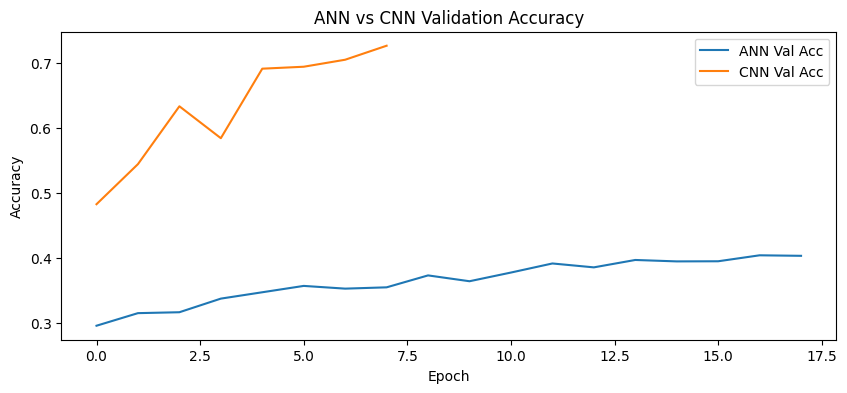

In [22]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(64, 3, activation='relu', padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm, y_test
)
print("Augmented CNN Test Accuracy:", aug_test_acc)

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 270s 380ms/step - accuracy: 0.3180 - loss: 1.9156 - val_accuracy: 0.4114 - val_loss: 1.6514
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 271s 384ms/step - accuracy: 0.4155 - loss: 1.6175 - val_accuracy: 0.5032 - val_loss: 1.3421
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 270s 383ms/step - accuracy: 0.4640 - loss: 1.4945 - val_accuracy: 0.5252 - val_loss: 1.3562
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4016 - loss: 1.6760
Augmented CNN Test Accuracy: 0.4016000032424927


# 📊 Final Comparison Table

In [24]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.3952
1,CNN,0.6810


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [25]:
# From 10 epochs
# Model	Test Accuracy
# 0	ANN	0.4310
# 1	CNN	0.7183


# from 20 epochs

# Model	Test Accuracy
# 0	ANN	0.3952
# 1	CNN	0.6810
